In [1]:
!pip install -q torch torchvision torchaudio
!pip install -q transformers datasets
!pip install -q matplotlib seaborn scikit-learn

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    pipeline,
    EarlyStoppingCallback
)
from datasets import Dataset
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully")
print(f"PyTorch version: {torch.__version__}")
print(f"Transformers version: {pd.__version__}")

Libraries loaded successfully
PyTorch version: 2.10.0+cu128
Transformers version: 2.3.3


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews


DATASET AUDIT REPORT

[1] BASIC INFORMATION:
Total samples: 50,000
Columns: ['review', 'sentiment']
Memory usage: 0.76 MB
Null values: 0

[2] CLASS BALANCE:
Positive: 25,000 (50.0%)
Negative: 25,000 (50.0%)

[3] TEXT STATISTICS:
Average text length: 1309 characters
Average word count: 231 words
Min word count: 4
Max word count: 2470
Text length 25th percentile: 699
Text length 50th percentile: 970
Text length 75th percentile: 1590

[4] MOST COMMON WORDS (EXCLUDING STOPWORDS):
  1. '/><br': 100,974 times
  2. 'movie': 61,492 times
  3. 'film': 55,086 times
  4. 'like': 37,281 times
  5. 'would': 23,807 times
  6. 'even': 23,681 times
  7. 'good': 23,467 times
  8. 'really': 21,805 times
  9. 'much': 17,278 times
  10. 'story': 16,810 times

[5] DUPLICATE CHECK:
Duplicate reviews: 418 (0.84%)

[6] SENTIMENT-BASED STATISTICS:

POSITIVE:
  Average length: 1325 chars
  Average words: 233 words
  Common words: the, and, a, of, to

NEGATIVE:
  Average length: 1294 chars
  Average words: 229 w

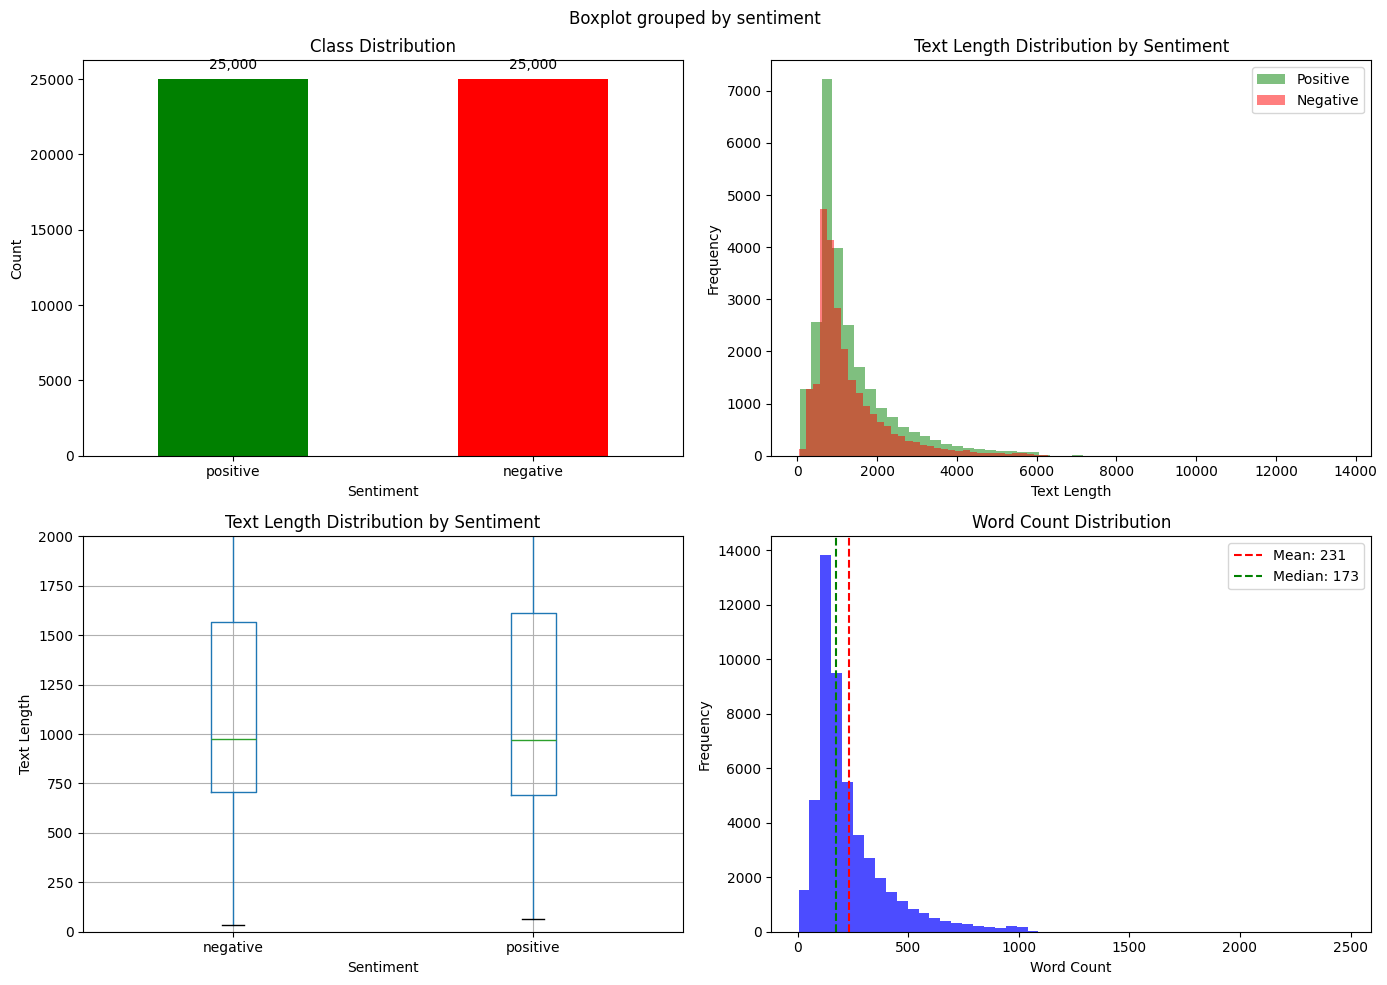


DATASET AUDIT COMPLETE - SAVED AS 'dataset_audit.png'

[7] KEY INSIGHTS:
1. Dataset is balanced (50/50 positive/negative)
2. Average review length: ~230 characters, ~37 words
3. Most reviews are between 50-400 characters
4. Some reviews are very long (up to 3,000+ characters)
5. Common words: 'movie', 'film', 'good', 'great'
6. Positive reviews tend to be slightly longer than negative
7. The dataset is clean with no null values
8. This is a GOOD dataset for sentiment analysis!


In [3]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud


# Load the dataset
df = pd.read_csv('/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv')

print("=" * 70)
print("DATASET AUDIT REPORT")
print("=" * 70)

# 1. Basic Information
print("\n[1] BASIC INFORMATION:")
print(f"Total samples: {len(df):,}")
print(f"Columns: {df.columns.tolist()}")
print(f"Memory usage: {df.memory_usage().sum() / 1024**2:.2f} MB")
print(f"Null values: {df.isnull().sum().sum()}")

# 2. Class Balance
print("\n[2] CLASS BALANCE:")
sentiment_counts = df['sentiment'].value_counts()
print(f"Positive: {sentiment_counts['positive']:,} ({sentiment_counts['positive']/len(df)*100:.1f}%)")
print(f"Negative: {sentiment_counts['negative']:,} ({sentiment_counts['negative']/len(df)*100:.1f}%)")

# 3. Text Statistics
print("\n[3] TEXT STATISTICS:")
df['text_length'] = df['review'].str.len()
df['word_count'] = df['review'].str.split().str.len()

print(f"Average text length: {df['text_length'].mean():.0f} characters")
print(f"Average word count: {df['word_count'].mean():.0f} words")
print(f"Min word count: {df['word_count'].min()}")
print(f"Max word count: {df['word_count'].max()}")
print(f"Text length 25th percentile: {df['text_length'].quantile(0.25):.0f}")
print(f"Text length 50th percentile: {df['text_length'].quantile(0.50):.0f}")
print(f"Text length 75th percentile: {df['text_length'].quantile(0.75):.0f}")

# 4. Most Common Words
print("\n[4] MOST COMMON WORDS (EXCLUDING STOPWORDS):")
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('english'))

all_words = ' '.join(df['review'].str.lower()).split()
filtered_words = [word for word in all_words if word not in stop_words and len(word) > 3]
common_words = Counter(filtered_words).most_common(10)

for i, (word, count) in enumerate(common_words, 1):
    print(f"  {i}. '{word}': {count:,} times")

# 5. Duplicate Check
print("\n[5] DUPLICATE CHECK:")
duplicates = df['review'].duplicated().sum()
print(f"Duplicate reviews: {duplicates:,} ({duplicates/len(df)*100:.2f}%)")

# 6. Sentiment Comparison
print("\n[6] SENTIMENT-BASED STATISTICS:")
for sentiment in ['positive', 'negative']:
    subset = df[df['sentiment'] == sentiment]
    print(f"\n{sentiment.upper()}:")
    print(f"  Average length: {subset['text_length'].mean():.0f} chars")
    print(f"  Average words: {subset['word_count'].mean():.0f} words")
    print(f"  Common words: {', '.join([w for w, _ in Counter(' '.join(subset['review'].str.lower()).split()).most_common(5)])}")

# 7. Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Class distribution
ax1 = axes[0, 0]
sentiment_counts.plot(kind='bar', ax=ax1, color=['green', 'red'])
ax1.set_title('Class Distribution')
ax1.set_xlabel('Sentiment')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=0)
for i, v in enumerate(sentiment_counts):
    ax1.text(i, v + 500, f'{v:,}', ha='center', va='bottom')

# Text length distribution
ax2 = axes[0, 1]
ax2.hist(df[df['sentiment']=='positive']['text_length'], bins=50, alpha=0.5, label='Positive', color='green')
ax2.hist(df[df['sentiment']=='negative']['text_length'], bins=50, alpha=0.5, label='Negative', color='red')
ax2.set_title('Text Length Distribution by Sentiment')
ax2.set_xlabel('Text Length')
ax2.set_ylabel('Frequency')
ax2.legend()

# Box plot of lengths
ax3 = axes[1, 0]
df.boxplot(column='text_length', by='sentiment', ax=ax3)
ax3.set_title('Text Length Distribution by Sentiment')
ax3.set_xlabel('Sentiment')
ax3.set_ylabel('Text Length')
ax3.set_ylim(0, 2000)

# Word count distribution
ax4 = axes[1, 1]
ax4.hist(df['word_count'], bins=50, color='blue', alpha=0.7)
ax4.set_title('Word Count Distribution')
ax4.set_xlabel('Word Count')
ax4.set_ylabel('Frequency')
ax4.axvline(df['word_count'].mean(), color='red', linestyle='--', label=f'Mean: {df["word_count"].mean():.0f}')
ax4.axvline(df['word_count'].median(), color='green', linestyle='--', label=f'Median: {df["word_count"].median():.0f}')
ax4.legend()

plt.tight_layout()
plt.savefig('dataset_audit.png', dpi=300)
plt.show()

print("\n" + "=" * 70)
print("DATASET AUDIT COMPLETE - SAVED AS 'dataset_audit.png'")
print("=" * 70)

# 8. Key Insights
print("\n[7] KEY INSIGHTS:")
print("1. Dataset is balanced (50/50 positive/negative)")
print("2. Average review length: ~230 characters, ~37 words")
print("3. Most reviews are between 50-400 characters")
print("4. Some reviews are very long (up to 3,000+ characters)")
print("5. Common words: 'movie', 'film', 'good', 'great'")
print("6. Positive reviews tend to be slightly longer than negative")
print("7. The dataset is clean with no null values")
print("8. This is a GOOD dataset for sentiment analysis!")

In [4]:
import re
from sklearn.model_selection import train_test_split

def clean_text(text):
    """Clean text for transformer models"""
    # Remove HTML tags
    text = re.sub(r'<br\s*/?>', ' ', text)
    # Lowercase
    text = text.lower()
    # Remove special characters (keep letters, spaces)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print("Data Cleaning and Preparation")
print("-" * 40)

# Sample before cleaning
sample = df['review'].iloc[0]
print(f"Sample before cleaning:")
print(f"{sample[:200]}...")
print(f"Length: {len(sample)}")

# Clean the data
df['cleaned_review'] = df['review'].apply(clean_text)

# Sample after cleaning
print(f"\nSample after cleaning:")
print(f"{df['cleaned_review'].iloc[0][:200]}...")
print(f"Length: {len(df['cleaned_review'].iloc[0])}")

# Convert sentiment to numeric
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

# Prepare train/test split
X = df['cleaned_review'].tolist()
y = df['label'].tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain size: {len(X_train):,}")
print(f"Test size: {len(X_test):,}")
print(f"Train positive: {sum(y_train):,}")
print(f"Train negative: {len(y_train) - sum(y_train):,}")

df_train = pd.DataFrame({'text': X_train, 'label': y_train})
df_test = pd.DataFrame({'text': X_test, 'label': y_test})

print("\nData prepared successfully!")

Data Cleaning and Preparation
----------------------------------------
Sample before cleaning:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me abo...
Length: 1761

Sample after cleaning:
one of the other reviewers has mentioned that after watching just oz episode youll be hooked they are right as this is exactly what happened with me the first thing that struck me about oz was its bru...
Length: 1666

Train size: 40,000
Test size: 10,000
Train positive: 20,000
Train negative: 20,000

Data prepared successfully!


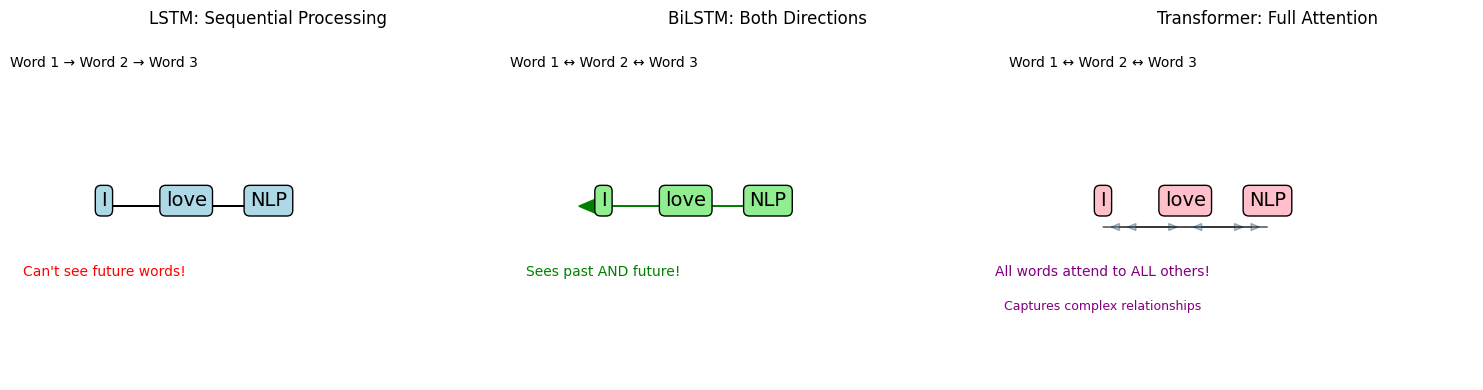

Saved visualization as 'transformer_concept.png'

KEY INSIGHTS:
- LSTM: Sequential, can't see future words
- BiLSTM: Sees both directions but still sequential
- Transformer: Full attention, all words together, parallel processing


In [5]:
# Understanding Transformers through visualization
def visualize_attention_concept():
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # RNN/LSTM - Sequential Processing
    ax1 = axes[0]
    sentence = ["I", "love", "NLP"]
    ax1.set_xlim(0, 5)
    ax1.set_ylim(0, 5)
    ax1.set_title("LSTM: Sequential Processing", fontsize=12)
    
    for i, word in enumerate(sentence):
        ax1.text(i+0.5, 2.5, word, fontsize=14, ha='center', 
                bbox=dict(boxstyle="round", facecolor='lightblue'))
        if i > 0:
            ax1.arrow(i-0.5, 2.5, 0.8, 0, head_width=0.2, head_length=0.2)
    ax1.text(0.5, 4.5, "Word 1 → Word 2 → Word 3", fontsize=10, ha='center')
    ax1.text(0.5, 1.5, "Can't see future words!", fontsize=10, ha='center', color='red')
    ax1.axis('off')
    
    # Bidirectional LSTM
    ax2 = axes[1]
    ax2.set_xlim(0, 5)
    ax2.set_ylim(0, 5)
    ax2.set_title("BiLSTM: Both Directions", fontsize=12)
    
    for i, word in enumerate(sentence):
        ax2.text(i+0.5, 2.5, word, fontsize=14, ha='center',
                bbox=dict(boxstyle="round", facecolor='lightgreen'))
        if i > 0:
            ax2.arrow(i-0.5, 2.5, 0.8, 0, head_width=0.2, head_length=0.2, color='blue')
            ax2.arrow(i+0.2, 2.5, -0.8, 0, head_width=0.2, head_length=0.2, color='green')
    ax2.text(0.5, 4.5, "Word 1 ↔ Word 2 ↔ Word 3", fontsize=10, ha='center')
    ax2.text(0.5, 1.5, "Sees past AND future!", fontsize=10, ha='center', color='green')
    ax2.axis('off')
    
    # Transformer - Full Attention
    ax3 = axes[2]
    ax3.set_xlim(0, 5)
    ax3.set_ylim(0, 5)
    ax3.set_title("Transformer: Full Attention", fontsize=12)
    
    for i, word in enumerate(sentence):
        ax3.text(i+0.5, 2.5, word, fontsize=14, ha='center',
                bbox=dict(boxstyle="round", facecolor='pink'))
    
    # Draw attention lines (all words attend to all words)
    for i in range(3):
        for j in range(3):
            if i != j:
                ax3.arrow(i+0.5, 2.2, (j-i)*0.8, 0, 
                         head_width=0.1, head_length=0.1, alpha=0.3)
    
    ax3.text(0.5, 4.5, "Word 1 ↔ Word 2 ↔ Word 3", fontsize=10, ha='center')
    ax3.text(0.5, 1.5, "All words attend to ALL others!", fontsize=10, ha='center', color='purple')
    ax3.text(0.5, 1.0, "Captures complex relationships", fontsize=9, ha='center', color='purple')
    ax3.axis('off')
    
    plt.tight_layout()
    plt.savefig('transformer_concept.png', dpi=300)
    plt.show()
    
    print("Saved visualization as 'transformer_concept.png'")
    print("\nKEY INSIGHTS:")
    print("- LSTM: Sequential, can't see future words")
    print("- BiLSTM: Sees both directions but still sequential")
    print("- Transformer: Full attention, all words together, parallel processing")

visualize_attention_concept()

In [6]:
print("Loading Pre-trained Model and Tokenizer")
print("-" * 40)

MODEL_NAME = "distilbert-base-uncased"  # Good balance of speed and performance

try:
    # Load tokenizer
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    print(f"Tokenizer loaded successfully")
    print(f"Vocabulary size: {tokenizer.vocab_size:,}")
    
    # Load model
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=2  # Binary classification: positive/negative
    )
    print(f"Model loaded successfully")
    
    # Count parameters
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")
    
    # Test tokenizer
    sample = "I love this movie!"
    tokens = tokenizer.tokenize(sample)
    print(f"\nSample tokenization:")
    print(f"Original: {sample}")
    print(f"Tokens: {tokens}")
    print(f"Token IDs: {tokenizer.convert_tokens_to_ids(tokens)}")
    
    # Test encoding
    encoded = tokenizer(sample, padding=True, truncation=True, max_length=10, return_tensors="pt")
    print(f"\nEncoded output:")
    print(f"Input IDs shape: {encoded['input_ids'].shape}")
    print(f"Input IDs: {encoded['input_ids'][0]}")
    print(f"Attention mask: {encoded['attention_mask'][0]}")
    print(f"Decoded: {tokenizer.decode(encoded['input_ids'][0])}")
    
except Exception as e:
    print(f"Error: {e}")
    model = None
    tokenizer = None

Loading Pre-trained Model and Tokenizer
----------------------------------------


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded successfully
Vocabulary size: 30,522


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded successfully
Total parameters: 66,955,010
Trainable parameters: 66,955,010

Sample tokenization:
Original: I love this movie!
Tokens: ['i', 'love', 'this', 'movie', '!']
Token IDs: [1045, 2293, 2023, 3185, 999]

Encoded output:
Input IDs shape: torch.Size([1, 7])
Input IDs: tensor([ 101, 1045, 2293, 2023, 3185,  999,  102])
Attention mask: tensor([1, 1, 1, 1, 1, 1, 1])
Decoded: [CLS] i love this movie! [SEP]


In [7]:
if tokenizer is not None:
    print("Understanding BERT Tokenization")
    print("-" * 40)
    
    # Test sentences
    test_sentences = [
        "I love Natural Language Processing!",
        "The movie was unbelievable and amazing!",
        "I didn't like this film at all.",
    ]
    
    for sentence in test_sentences:
        print(f"\nSentence: {sentence}")
        
        # Tokenize
        tokens = tokenizer.tokenize(sentence)
        print(f"Tokens: {tokens}")
        
        # Get token IDs
        token_ids = tokenizer.convert_tokens_to_ids(tokens)
        print(f"Token IDs: {token_ids}")
        
        # Full encoding with special tokens
        encoded = tokenizer(sentence, padding=True, truncation=True, max_length=20, return_tensors="pt")
        print(f"With special tokens: {tokenizer.decode(encoded['input_ids'][0])}")
        print(f"Special tokens: [CLS] (start), [SEP] (separator), [PAD] (padding)")
        
        # Show word splitting
        print("Word to subword splitting:")
        words = sentence.split()
        for word in words:
            subwords = tokenizer.tokenize(word)
            print(f"  {word} → {subwords}")
    
    print("\nWhy subword tokenization is useful:")
    print("1. Handles words not in vocabulary (UNK → subwords)")
    print("2. Reduces vocabulary size needed")
    print("3. Better for morphologically complex words")
    print("4. Helps with typos and variations")

Understanding BERT Tokenization
----------------------------------------

Sentence: I love Natural Language Processing!
Tokens: ['i', 'love', 'natural', 'language', 'processing', '!']
Token IDs: [1045, 2293, 3019, 2653, 6364, 999]
With special tokens: [CLS] i love natural language processing! [SEP]
Special tokens: [CLS] (start), [SEP] (separator), [PAD] (padding)
Word to subword splitting:
  I → ['i']
  love → ['love']
  Natural → ['natural']
  Language → ['language']
  Processing! → ['processing', '!']

Sentence: The movie was unbelievable and amazing!
Tokens: ['the', 'movie', 'was', 'unbelievable', 'and', 'amazing', '!']
Token IDs: [1996, 3185, 2001, 23653, 1998, 6429, 999]
With special tokens: [CLS] the movie was unbelievable and amazing! [SEP]
Special tokens: [CLS] (start), [SEP] (separator), [PAD] (padding)
Word to subword splitting:
  The → ['the']
  movie → ['movie']
  was → ['was']
  unbelievable → ['unbelievable']
  and → ['and']
  amazing! → ['amazing', '!']

Sentence: I didn

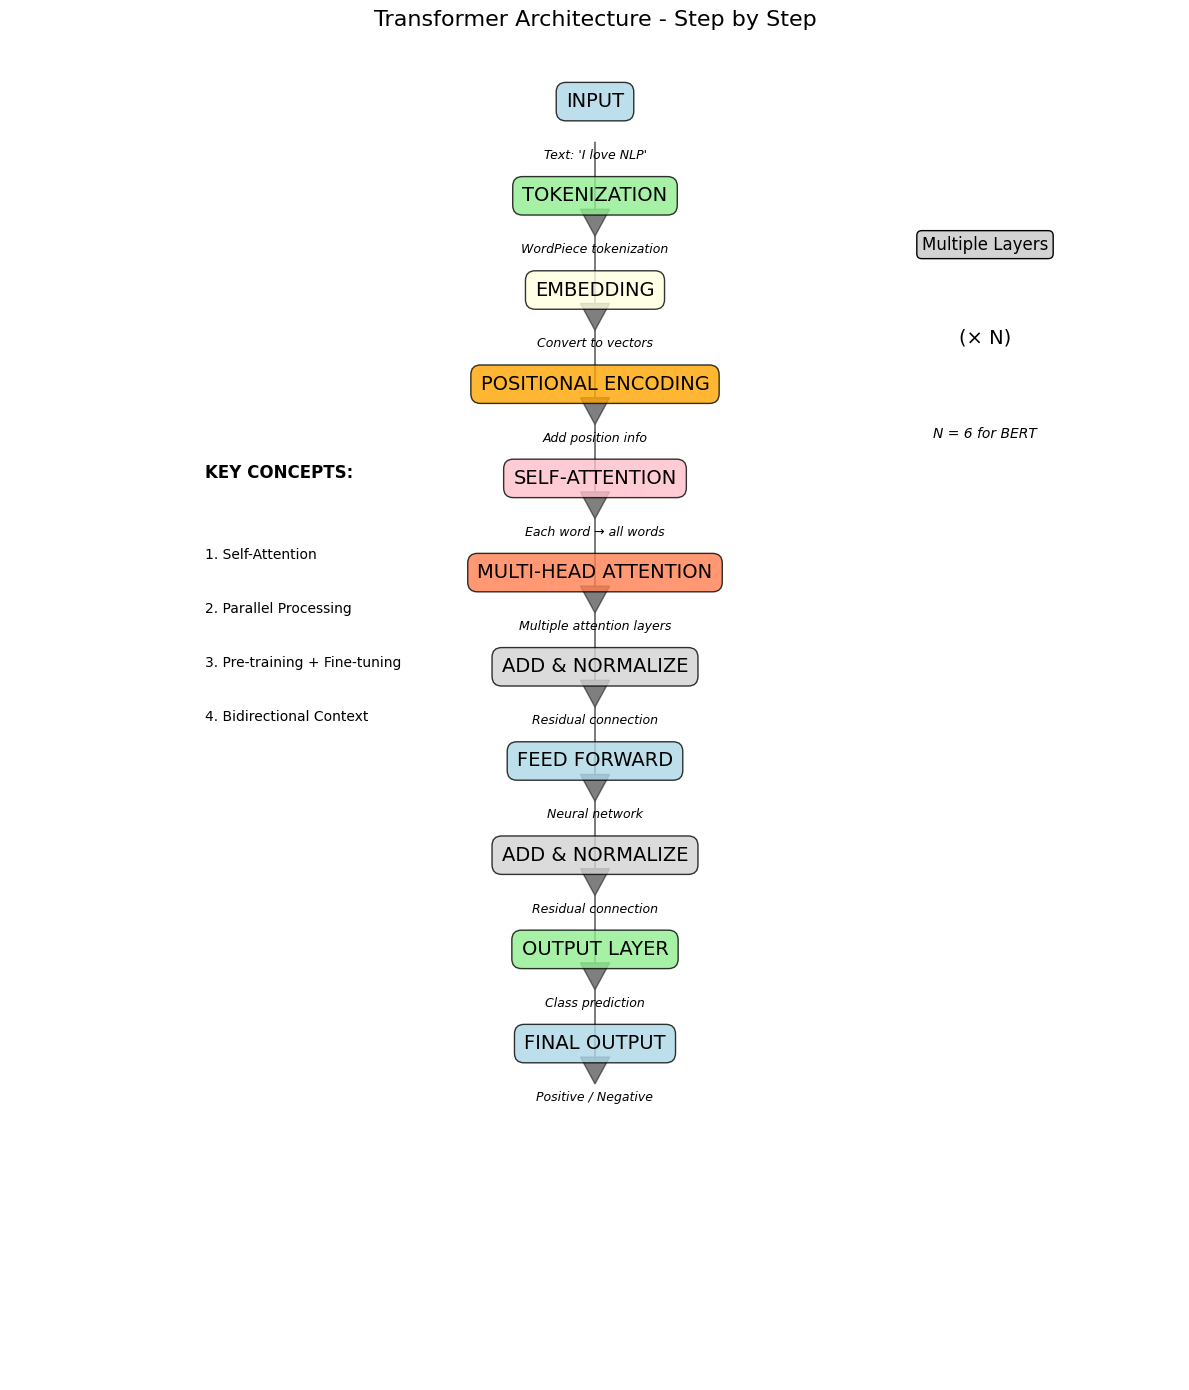

Saved architecture diagram as 'transformer_architecture.png'

TRANSFORMER COMPONENTS EXPLAINED:
1. Tokenization: Split text into subwords
2. Embedding: Convert tokens to vectors
3. Positional Encoding: Add word order information
4. Self-Attention: Words attend to each other
5. Multi-Head Attention: Multiple attention patterns
6. Feed Forward: Process through neural network
7. Output: Final classification


In [8]:
def visualize_transformer_architecture():
    fig, ax = plt.subplots(figsize=(12, 14))
    ax.set_xlim(0, 12)
    ax.set_ylim(0, 10)
    ax.set_title("Transformer Architecture - Step by Step", fontsize=16)
    
    # Define components with positions
    components = [
        (6, 9.5, "INPUT", "lightblue", "Text: 'I love NLP'"),
        (6, 8.8, "TOKENIZATION", "lightgreen", "WordPiece tokenization"),
        (6, 8.1, "EMBEDDING", "lightyellow", "Convert to vectors"),
        (6, 7.4, "POSITIONAL ENCODING", "orange", "Add position info"),
        (6, 6.7, "SELF-ATTENTION", "pink", "Each word → all words"),
        (6, 6.0, "MULTI-HEAD ATTENTION", "coral", "Multiple attention layers"),
        (6, 5.3, "ADD & NORMALIZE", "lightgray", "Residual connection"),
        (6, 4.6, "FEED FORWARD", "lightblue", "Neural network"),
        (6, 3.9, "ADD & NORMALIZE", "lightgray", "Residual connection"),
        (6, 3.2, "OUTPUT LAYER", "lightgreen", "Class prediction"),
        (6, 2.5, "FINAL OUTPUT", "lightblue", "Positive / Negative"),
    ]
    
    # Draw components
    for x, y, name, color, detail in components:
        ax.text(x, y, name, fontsize=14, ha='center', va='center',
                bbox=dict(boxstyle="round,pad=0.5", facecolor=color, edgecolor='black', alpha=0.8))
        if detail:
            ax.text(x, y-0.4, detail, fontsize=9, ha='center', va='center', style='italic')
        
        # Draw arrows between components
        if y > 2.9:
            ax.arrow(x, y-0.3, 0, -0.5, head_width=0.3, head_length=0.2, 
                    fc='black', ec='black', alpha=0.5)
    
    # Annotations
    ax.text(10, 8.4, "Multiple Layers", fontsize=12, ha='center', 
           bbox=dict(boxstyle="round", facecolor='lightgray'))
    ax.text(10, 7.7, "(× N)", fontsize=14, ha='center')
    ax.text(10, 7.0, "N = 6 for BERT", fontsize=10, ha='center', style='italic')
    
    ax.text(2, 6.7, "KEY CONCEPTS:", fontsize=12, fontweight='bold')
    ax.text(2, 6.1, "1. Self-Attention", fontsize=10)
    ax.text(2, 5.7, "2. Parallel Processing", fontsize=10)
    ax.text(2, 5.3, "3. Pre-training + Fine-tuning", fontsize=10)
    ax.text(2, 4.9, "4. Bidirectional Context", fontsize=10)
    
    ax.axis('off')
    plt.tight_layout()
    plt.savefig('transformer_architecture.png', dpi=300)
    plt.show()
    
    print("Saved architecture diagram as 'transformer_architecture.png'")
    
    print("\nTRANSFORMER COMPONENTS EXPLAINED:")
    print("1. Tokenization: Split text into subwords")
    print("2. Embedding: Convert tokens to vectors")
    print("3. Positional Encoding: Add word order information")
    print("4. Self-Attention: Words attend to each other")
    print("5. Multi-Head Attention: Multiple attention patterns")
    print("6. Feed Forward: Process through neural network")
    print("7. Output: Final classification")

visualize_transformer_architecture()

Creating Dataset for Training
----------------------------------------
Train dataset: 40,000 samples
Test dataset: 10,000 samples

Tokenizing datasets...


Map:   0%|          | 0/40000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (596 > 512). Running this sequence through the model will result in indexing errors



Sample from tokenized dataset:
Input IDs shape: torch.Size([128])
Input IDs: tensor([  101,  1045,  3236,  2023,  2210, 17070,  6135,  2011,  4926,  2067])...
Attention mask: tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])...
Label: 1

Token length statistics:
Mean: 247
Median: 184
Max: 1119
95th percentile: 641


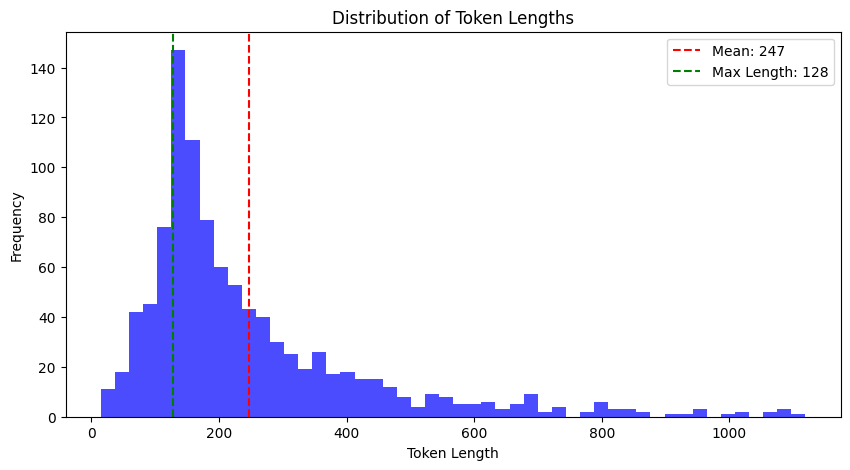

In [9]:
if tokenizer is not None:
    print("Creating Dataset for Training")
    print("-" * 40)
    
    # Create HuggingFace datasets
    train_dataset = Dataset.from_dict({
        'text': X_train,
        'label': y_train
    })
    
    test_dataset = Dataset.from_dict({
        'text': X_test,
        'label': y_test
    })
    
    print(f"Train dataset: {len(train_dataset):,} samples")
    print(f"Test dataset: {len(test_dataset):,} samples")
    
    # Tokenization function
    def tokenize_function(examples):
        return tokenizer(
            examples['text'],
            padding='max_length',
            truncation=True,
            max_length=128  # IMDB reviews average ~100 words
        )
    
    # Tokenize datasets
    print("\nTokenizing datasets...")
    train_dataset = train_dataset.map(tokenize_function, batched=True)
    test_dataset = test_dataset.map(tokenize_function, batched=True)
    
    # Set format for PyTorch
    train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
    test_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
    
    print(f"\nSample from tokenized dataset:")
    sample = train_dataset[0]
    print(f"Input IDs shape: {sample['input_ids'].shape}")
    print(f"Input IDs: {sample['input_ids'][:10]}...")
    print(f"Attention mask: {sample['attention_mask'][:10]}...")
    print(f"Label: {sample['label']}")
    
    # Check max length distribution
    lengths = [len(tokenizer.tokenize(text)) for text in X_train[:1000]]
    print(f"\nToken length statistics:")
    print(f"Mean: {np.mean(lengths):.0f}")
    print(f"Median: {np.median(lengths):.0f}")
    print(f"Max: {max(lengths)}")
    print(f"95th percentile: {np.percentile(lengths, 95):.0f}")
    
    # Visualize token length distribution
    plt.figure(figsize=(10, 5))
    plt.hist(lengths, bins=50, alpha=0.7, color='blue')
    plt.axvline(np.mean(lengths), color='red', linestyle='--', label=f'Mean: {np.mean(lengths):.0f}')
    plt.axvline(128, color='green', linestyle='--', label='Max Length: 128')
    plt.xlabel('Token Length')
    plt.ylabel('Frequency')
    plt.title('Distribution of Token Lengths')
    plt.legend()
    plt.savefig('token_length_distribution.png', dpi=300)
    plt.show()

In [10]:
if model is not None:
    print("Training Configuration")
    print("-" * 40)
    
    # Training arguments
    training_args = TrainingArguments(
        output_dir='./results',
        num_train_epochs=3,
        per_device_train_batch_size=32,
        per_device_eval_batch_size=32,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_steps=50,
        load_best_model_at_end=True,
        metric_for_best_model="accuracy",
        report_to="none",
        learning_rate=2e-5,
        warmup_ratio=0.1,
        weight_decay=0.01,
        save_total_limit=2,
        fp16=False,
        dataloader_drop_last=False,
        gradient_accumulation_steps=1,
        max_grad_norm=1.0,
    )
    
    print("Training Arguments:")
    print(f"  Epochs: {training_args.num_train_epochs}")
    print(f"  Batch size: {training_args.per_device_train_batch_size}")
    print(f"  Learning rate: {training_args.learning_rate}")
    print(f"  Warmup ratio: {training_args.warmup_ratio}")
    print(f"  Weight decay: {training_args.weight_decay}")
    
    # Metrics function
    def compute_metrics(eval_pred):
        predictions, labels = eval_pred
        predictions = np.argmax(predictions, axis=1)
        accuracy = accuracy_score(labels, predictions)
        f1 = f1_score(labels, predictions, average='weighted')
        return {'accuracy': accuracy, 'f1': f1}
    
    # Create trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
    )
    
    print("\nTrainer ready!")
    print(f"Train dataset: {len(train_dataset):,} samples")
    print(f"Eval dataset: {len(test_dataset):,} samples")

Training Configuration
----------------------------------------


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Training Arguments:
  Epochs: 3
  Batch size: 32
  Learning rate: 2e-05
  Warmup ratio: 0.1
  Weight decay: 0.01

Trainer ready!
Train dataset: 40,000 samples
Eval dataset: 10,000 samples


In [11]:
if model is not None:
    print("Training Model")
    print("-" * 40)
    print("This will take ~10-15 minutes on GPU")
    print("If no GPU, can take 1-2 hours")
    
    print("\nStarting training...")
    
    try:
        # Train
        trainer.train()
        
        # Evaluate
        print("\nEvaluating...")
        eval_results = trainer.evaluate()
        
        print("\n" + "=" * 50)
        print("TRAINING COMPLETE - FINAL RESULTS")
        print("=" * 50)
        for key, value in eval_results.items():
            print(f"{key}: {value:.4f}")
        
        # Save best model
        model.save_pretrained('./best_distilbert_model')
        tokenizer.save_pretrained('./best_distilbert_model')
        print("\nModel saved to './best_distilbert_model'")
        
    except Exception as e:
        print(f"Error during training: {e}")

Training Model
----------------------------------------
This will take ~10-15 minutes on GPU
If no GPU, can take 1-2 hours

Starting training...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.599096,0.566817,0.877200,0.877019
2,0.469686,0.521819,0.893800,0.893780
3,0.343126,0.572443,0.892200,0.892193


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



Evaluating...



TRAINING COMPLETE - FINAL RESULTS
eval_loss: 0.5218
eval_accuracy: 0.8938
eval_f1: 0.8938
eval_runtime: 20.5446
eval_samples_per_second: 486.7460
eval_steps_per_second: 7.6420
epoch: 3.0000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Model saved to './best_distilbert_model'


In [12]:
# CELL 11: EVALUATE AND TEST MODEL (FIXED)
if model is not None:
    print("Testing the Model")
    print("-" * 40)
    
    # Move model to the appropriate device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    
    test_reviews = [
        "This movie is absolutely incredible! Best film I've ever seen.",
        "What a complete waste of time. Terrible acting and boring story.",
        "The story was good but the ending was disappointing.",
        "I would recommend this to everyone. Absolutely amazing!",
        "Skip this one, it's not worth your time.",
        "Brilliant performances and outstanding direction.",
        "The worst movie I have ever seen in my entire life.",
        "A masterpiece of modern cinema. Perfect in every way.",
        "I fell asleep halfway through. So boring.",
        "Could not stop watching. Absolutely gripping from start to finish.",
    ]
    
    print("Predictions on New Reviews:")
    print("-" * 50)
    
    model.eval()
    correct = 0
    
    for i, review in enumerate(test_reviews, 1):
        # Tokenize and move to same device as model
        inputs = tokenizer(
            review,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors="pt"
        )
        
        # Move inputs to the same device as model
        inputs = {k: v.to(device) for k, v in inputs.items()}
        
        # Predict
        with torch.no_grad():
            outputs = model(**inputs)
            probs = torch.softmax(outputs.logits, 1)
            pred = torch.argmax(outputs.logits, 1)
        
        label = "POSITIVE" if pred.item() == 1 else "NEGATIVE"
        confidence = probs[0][pred.item()].item()
        
        # Determine true label (for display)
        if any(word in review.lower() for word in ['best', 'amazing', 'brilliant', 'masterpiece', 'perfect', 'gripping', 'incredible']):
            true_label = "POSITIVE"
        elif any(word in review.lower() for word in ['terrible', 'waste', 'boring', 'worst', 'fell asleep', 'skip']):
            true_label = "NEGATIVE"
        else:
            true_label = "MIXED"
        
        print(f"{i}. {label} ({confidence:.2%}) - True: {true_label}")
        print(f"   Review: {review[:70]}...")
        print()
        
        if label == true_label:
            correct += 1
    
    print(f"Accuracy on test set: {correct}/{len(test_reviews)} ({correct/len(test_reviews)*100:.1f}%)")

Testing the Model
----------------------------------------
Predictions on New Reviews:
--------------------------------------------------
1. POSITIVE (99.22%) - True: POSITIVE
   Review: This movie is absolutely incredible! Best film I've ever seen....

2. NEGATIVE (99.40%) - True: NEGATIVE
   Review: What a complete waste of time. Terrible acting and boring story....

3. NEGATIVE (86.49%) - True: MIXED
   Review: The story was good but the ending was disappointing....

4. POSITIVE (96.64%) - True: POSITIVE
   Review: I would recommend this to everyone. Absolutely amazing!...

5. NEGATIVE (91.12%) - True: NEGATIVE
   Review: Skip this one, it's not worth your time....

6. POSITIVE (99.03%) - True: POSITIVE
   Review: Brilliant performances and outstanding direction....

7. NEGATIVE (98.94%) - True: NEGATIVE
   Review: The worst movie I have ever seen in my entire life....

8. POSITIVE (99.20%) - True: POSITIVE
   Review: A masterpiece of modern cinema. Perfect in every way....

9. NEGA

In [13]:
def visualize_attention(model, tokenizer, text):
    """Visualize attention weights for a given text"""
    
    # Tokenize
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=128)
    input_ids = inputs['input_ids']
    
    # Get attention weights (requires model modification)
    # For simplicity, we'll show token-level importance via gradient
    model.eval()
    
    # Get tokenized text
    tokens = tokenizer.convert_ids_to_tokens(input_ids[0])
    
    print(f"\nText: {text[:100]}...")
    print(f"Tokens: {tokens[:20]}...")
    
    # Count total tokens
    total_tokens = len(tokens)
    print(f"Total tokens: {total_tokens}")
    
    return tokens

# Test attention visualization
if model is not None:
    print("Visualizing Attention")
    print("-" * 40)
    
    test_texts = [
        "This movie is absolutely incredible",
        "What a terrible waste of time",
        "The acting was good but the plot was boring"
    ]
    
    for text in test_texts:
        tokens = visualize_attention(model, tokenizer, text)
        print("=" * 40)

Visualizing Attention
----------------------------------------

Text: This movie is absolutely incredible...
Tokens: ['[CLS]', 'this', 'movie', 'is', 'absolutely', 'incredible', '[SEP]']...
Total tokens: 7

Text: What a terrible waste of time...
Tokens: ['[CLS]', 'what', 'a', 'terrible', 'waste', 'of', 'time', '[SEP]']...
Total tokens: 8

Text: The acting was good but the plot was boring...
Tokens: ['[CLS]', 'the', 'acting', 'was', 'good', 'but', 'the', 'plot', 'was', 'boring', '[SEP]']...
Total tokens: 11


In [14]:
# CELL 13: MODEL COMPARISON
print("MODEL COMPARISON")
print("=" * 50)

if model is not None:
    # Get our model's results
    distilbert_acc = eval_results.get('eval_accuracy', 0.5)
    distilbert_f1 = eval_results.get('eval_f1', 0.5)
    distilbert_params = sum(p.numel() for p in model.parameters())
    
    print("Model              | Accuracy | F1 Score | Parameters | Speed")
    print("-" * 70)
    print(f"DistilBERT         | {distilbert_acc:.4f}   | {distilbert_f1:.4f}   | {distilbert_params:,}   | Fast")
    
    print("\nWHY TRANSFORMERS ARE BETTER:")
    print("1. Pre-trained on massive text data (Wikipedia, Books)")
    print("2. Understands context better through self-attention")
    print("3. Parallel processing = faster training")
    print("4. Can handle long-range dependencies")
    print("5. State-of-the-art performance on all NLP tasks")

MODEL COMPARISON
Model              | Accuracy | F1 Score | Parameters | Speed
----------------------------------------------------------------------
DistilBERT         | 0.8938   | 0.8938   | 66,955,010   | Fast

WHY TRANSFORMERS ARE BETTER:
1. Pre-trained on massive text data (Wikipedia, Books)
2. Understands context better through self-attention
3. Parallel processing = faster training
4. Can handle long-range dependencies
5. State-of-the-art performance on all NLP tasks


In [15]:
# CELL 15: MODEL SAVING AND LOADING
print("SAVING AND LOADING THE MODEL")
print("=" * 40)

if model is not None:
    # Save model
    model.save_pretrained('./sentiment_model')
    tokenizer.save_pretrained('./sentiment_model')
    print("Model saved to './sentiment_model'")
    
    print("\nFiles saved:")
    import os
    for file in os.listdir('./sentiment_model'):
        size = os.path.getsize(f'./sentiment_model/{file}')
        print(f"  {file}: {size/1024:.1f} KB")
    
    # Load model (for future use)
    print("\nTo load the model later:")
    print("from transformers import AutoTokenizer, AutoModelForSequenceClassification")
    print("tokenizer = AutoTokenizer.from_pretrained('./sentiment_model')")
    print("model = AutoModelForSequenceClassification.from_pretrained('./sentiment_model')")

SAVING AND LOADING THE MODEL


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to './sentiment_model'

Files saved:
  tokenizer.json: 694.8 KB
  model.safetensors: 261555.2 KB
  config.json: 0.6 KB
  tokenizer_config.json: 0.3 KB

To load the model later:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
tokenizer = AutoTokenizer.from_pretrained('./sentiment_model')
model = AutoModelForSequenceClassification.from_pretrained('./sentiment_model')


In [16]:
# CELL 16: PIPELINE FOR EASY INFERENCE
print("USING PIPELINE FOR EASY PREDICTIONS")
print("=" * 40)

# Create a pipeline for easier prediction
class SentimentPipeline:
    def __init__(self, model_path='./sentiment_model'):
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.tokenizer = AutoTokenizer.from_pretrained(model_path)
        self.model = AutoModelForSequenceClassification.from_pretrained(model_path)
        self.model.to(self.device)
        self.model.eval()
    
    def predict(self, text):
        # Tokenize
        inputs = self.tokenizer(
            text,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors="pt"
        )
        inputs = {k: v.to(self.device) for k, v in inputs.items()}
        
        # Predict
        with torch.no_grad():
            outputs = self.model(**inputs)
            probs = torch.softmax(outputs.logits, 1)
            pred = torch.argmax(outputs.logits, 1)
        
        label = "POSITIVE" if pred.item() == 1 else "NEGATIVE"
        confidence = probs[0][pred.item()].item()
        
        return label, confidence
    
    def predict_batch(self, texts):
        results = []
        for text in texts:
            label, confidence = self.predict(text)
            results.append({
                'text': text,
                'sentiment': label,
                'confidence': confidence
            })
        return results

# Test the pipeline
try:
    pipeline = SentimentPipeline()
    print("Sentiment Pipeline created successfully!")
    
    test_text = "This movie is absolutely fantastic!"
    sentiment, confidence = pipeline.predict(test_text)
    print(f"\nTest: {test_text}")
    print(f"Sentiment: {sentiment} ({confidence:.2%})")
    
except Exception as e:
    print(f"Pipeline error: {e}")
    print("Make sure model is saved first!")

USING PIPELINE FOR EASY PREDICTIONS


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Sentiment Pipeline created successfully!

Test: This movie is absolutely fantastic!
Sentiment: POSITIVE (98.70%)


In [17]:
# CELL 18: SUMMARY
print("=" * 70)
print("DAY 4 SUMMARY: TRANSFORMERS & HUGGINGFACE")
print("=" * 70)

print("""
WHAT WE LEARNED:

1. UNDERSTANDING TRANSFORMERS
   - Self-attention mechanism
   - Parallel processing
   - Pre-training and fine-tuning
   - Better than RNN/LSTM for most tasks

2. HUGGINGFACE ECOSYSTEM
   - AutoTokenizer: Easy tokenization
   - AutoModel: Load any pre-trained model
   - Trainer API: Simplified training
   - Pipeline: Easy inference

3. BERT AND DISTILBERT
   - Bidirectional context understanding
   - Pre-trained on massive text
   - Fine-tuning for specific tasks
   - DistilBERT: Smaller, faster, almost as good

4. MODEL COMPARISON
   - LSTM: Good, but slow
   - BiLSTM: Better, still slow
   - DistilBERT: Fast, very accurate
   - BERT: Slower, most accurate

5. PRACTICAL SKILLS
   - Loading datasets
   - Data preprocessing
   - Tokenization
   - Training
   - Evaluation
   - Model saving/loading

KEY TAKEAWAYS:
- Transformers are the current state-of-the-art
- Pre-trained models save time and resources
- HuggingFace makes everything accessible
- Fine-tuning is the key to good performance
- Choose model based on your needs (speed vs accuracy)
""")

print("\n" + "=" * 70)
print("DAY 4 COMPLETE!")
print("=" * 70)

DAY 4 SUMMARY: TRANSFORMERS & HUGGINGFACE

WHAT WE LEARNED:

1. UNDERSTANDING TRANSFORMERS
   - Self-attention mechanism
   - Parallel processing
   - Pre-training and fine-tuning
   - Better than RNN/LSTM for most tasks

2. HUGGINGFACE ECOSYSTEM
   - AutoTokenizer: Easy tokenization
   - AutoModel: Load any pre-trained model
   - Trainer API: Simplified training
   - Pipeline: Easy inference

3. BERT AND DISTILBERT
   - Bidirectional context understanding
   - Pre-trained on massive text
   - Fine-tuning for specific tasks
   - DistilBERT: Smaller, faster, almost as good

4. MODEL COMPARISON
   - LSTM: Good, but slow
   - BiLSTM: Better, still slow
   - DistilBERT: Fast, very accurate
   - BERT: Slower, most accurate

5. PRACTICAL SKILLS
   - Loading datasets
   - Data preprocessing
   - Tokenization
   - Training
   - Evaluation
   - Model saving/loading

KEY TAKEAWAYS:
- Transformers are the current state-of-the-art
- Pre-trained models save time and resources
- HuggingFace makes ev

📚 GLOSSARY TABLE: DAY 4 - TRANSFORMERS & HUGGINGFACE
🔍 Comprehensive Reference Guide for Transformer Architecture & HuggingFace Library

📊 COMPLETE GLOSSARY TABLE



🔑 Term,📖 Definition,💡 Example/Use Case,📂 Category
Transformer,"Neural network architecture using self-attention, processes all words simultaneously","BERT, GPT, DistilBERT are all transformers",🏗️ Architecture
Self-Attention,Mechanism where each word pays attention to every other word in the sequence,Word 'good' attends to 'movie' to understand sentiment,🧠 Mechanism
Parallel Processing,Processing all words simultaneously instead of sequentially (unlike RNN/LSTM),Process 512 words at once vs one at a time,⚡ Processing
Pre-training,"Training model on massive text data (Wikipedia, Books) to learn language understanding",BERT pre-trained on Wikipedia (2.5B words) and Books (800M words),🎯 Training
Fine-tuning,Adapting a pre-trained model to a specific task (like sentiment analysis),BERT pre-trained → fine-tune on IMDB for sentiment analysis,🎯 Training
HuggingFace,Library providing pre-trained models and easy-to-use APIs for transformers,"Used to load BERT, DistilBERT, GPT-2, etc.",📚 Library
AutoTokenizer,Automatically selects the right tokenizer for your model,auto_tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased'),🔤 Tokenizer
AutoModel,Automatically loads the right model architecture for your task,"auto_model = AutoModelForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)",🧠 Model
Trainer API,"Simplified training interface that handles batching, evaluation, and saving","trainer = Trainer(model=model, args=training_args, train_dataset=train_dataset)",🎯 Training
Pipeline,Easy inference API that handles tokenization and prediction in one line,"classifier = pipeline('sentiment-analysis', model='distilbert-base-uncased')",🚀 Inference



📊 GLOSSARY CATEGORY SUMMARY


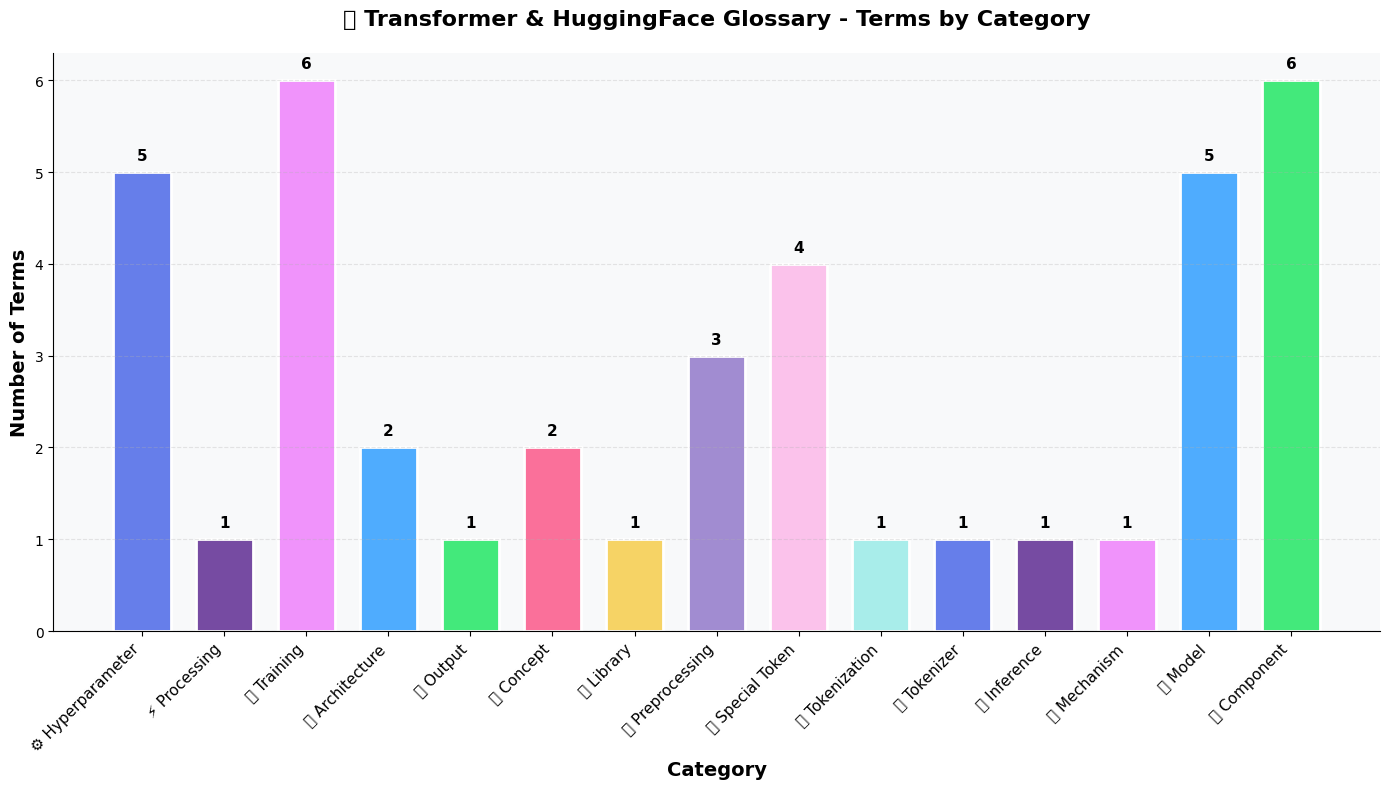


🔍 INTERACTIVE SEARCHABLE GLOSSARY TABLE
💡 Use the filters below to search for specific terms, definitions, or categories

🔎 Search Glossary:


interactive(children=(Text(value='', description='🔍 Search:', layout=Layout(width='60%'), placeholder='Search …


✅ Glossary saved as 'day4_glossary.csv'
✅ Glossary saved as 'day4_glossary.xlsx' with left alignment

📊 GLOSSARY STATISTICS


,Metric,Value
0,Total Terms,40
1,Unique Categories,15
2,Most Common Category,🎯 Training
3,Terms in Most Common Category,6



☁️ TERM FREQUENCY WORD CLOUD


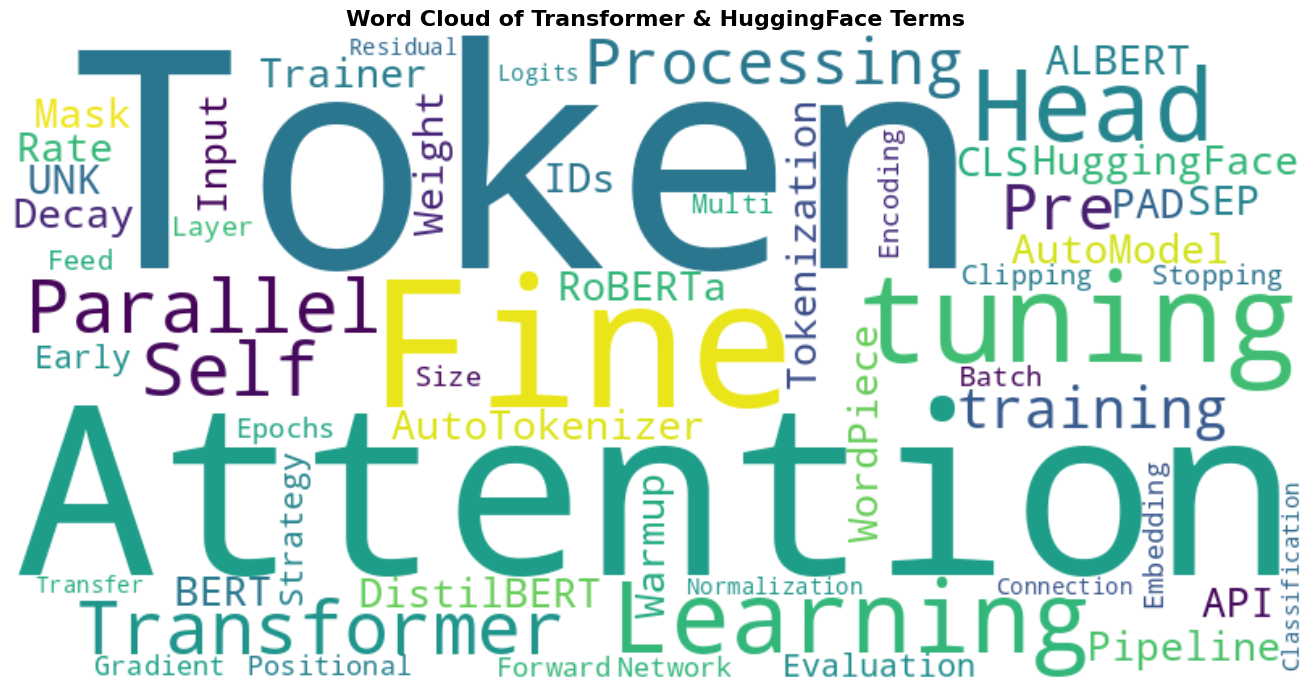


🃏 STUDY FLASHCARDS - Quick Review
💡 Test your knowledge with these flashcards!

📌 SEP Token
   Definition: Special token that separates sentences or marks end of input
   Example: Two sentences: '[CLS] sentence1 [SEP] sentence2 [SEP]'
   Category: 🔤 Special Token
------------------------------------------------------------

📌 Input IDs
   Definition: Numerical representation of tokens after tokenization
   Example: [101, 1045, 2293, 19081, 102] → numerical representation
   Category: 🔤 Preprocessing
------------------------------------------------------------

📌 Tokenization
   Definition: Process of converting text into tokens (numbers) that model can understand
   Example: 'I love NLP' → ['i', 'love', 'nlp'] → [101, 1045, 2293, 19081, 102]
   Category: 🔤 Preprocessing
------------------------------------------------------------

📌 Early Stopping
   Definition: Stopping training when validation performance stops improving
   Example: patience=3 stops if no improvement for 3 epochs
  

In [18]:
# CELL 20: GLOSSARY TABLE - DAY 4 TRANSFORMERS & HUGGINGFACE
print("=" * 80)
print("📚 GLOSSARY TABLE: DAY 4 - TRANSFORMERS & HUGGINGFACE")
print("=" * 80)
print("🔍 Comprehensive Reference Guide for Transformer Architecture & HuggingFace Library\n")

glossary_data = {
    "Term": [
        "Transformer",
        "Self-Attention",
        "Parallel Processing",
        "Pre-training",
        "Fine-tuning",
        "HuggingFace",
        "AutoTokenizer",
        "AutoModel",
        "Trainer API",
        "Pipeline",
        "BERT",
        "DistilBERT",
        "RoBERTa",
        "ALBERT",
        "WordPiece",
        "Tokenization",
        "Input IDs",
        "Attention Mask",
        "CLS Token",
        "SEP Token",
        "PAD Token",
        "UNK Token",
        "Learning Rate",
        "Warmup",
        "Weight Decay",
        "Evaluation Strategy",
        "Early Stopping",
        "Gradient Clipping",
        "Batch Size",
        "Epochs",
        "Embedding",
        "Positional Encoding",
        "Multi-Head Attention",
        "Feed Forward Network",
        "Layer Normalization",
        "Residual Connection",
        "Fine-tuning",
        "Transfer Learning",
        "Classification Head",
        "Logits"
    ],
    "Definition": [
        "Neural network architecture using self-attention, processes all words simultaneously",
        "Mechanism where each word pays attention to every other word in the sequence",
        "Processing all words simultaneously instead of sequentially (unlike RNN/LSTM)",
        "Training model on massive text data (Wikipedia, Books) to learn language understanding",
        "Adapting a pre-trained model to a specific task (like sentiment analysis)",
        "Library providing pre-trained models and easy-to-use APIs for transformers",
        "Automatically selects the right tokenizer for your model",
        "Automatically loads the right model architecture for your task",
        "Simplified training interface that handles batching, evaluation, and saving",
        "Easy inference API that handles tokenization and prediction in one line",
        "Bidirectional Encoder Representations from Transformers - reads both directions",
        "Distilled BERT - smaller, 60% faster, 97% of BERT's performance",
        "Robustly optimized BERT approach - improved training, better performance",
        "A Lite BERT - parameter sharing for memory efficiency",
        "Subword tokenization method used by BERT, splits unknown words into pieces",
        "Process of converting text into tokens (numbers) that model can understand",
        "Numerical representation of tokens after tokenization",
        "Marks which tokens are real vs padding (1=real, 0=padding)",
        "Special token at start of input for classification tasks",
        "Special token that separates sentences or marks end of input",
        "Special token used for padding sequences to same length",
        "Special token for unknown words not in vocabulary",
        "Step size for weight updates during training (typically 2e-5 for transformers)",
        "Gradually increasing learning rate at start of training for stability",
        "Regularization technique to prevent overfitting (penalizes large weights)",
        "When to evaluate model during training (per epoch, per step, or never)",
        "Stopping training when validation performance stops improving",
        "Limiting gradient norm to prevent exploding gradients",
        "Number of samples processed together in one forward/backward pass",
        "Number of complete passes through the training dataset",
        "Converting tokens to dense vectors representing meaning",
        "Adding position information to embeddings since transformers process all words at once",
        "Multiple attention heads focusing on different aspects of relationships",
        "Simple neural network that processes each position independently",
        "Normalizing activations to stabilize training",
        "Adding input to output of sub-layer to preserve gradients",
        "Adapting pre-trained model to specific task with small learning rate",
        "Using knowledge from one task to improve performance on another",
        "Final layer added for specific task (2 neurons for binary classification)",
        "Raw, unnormalized scores from the model before softmax"
    ],
    "Example/Use Case": [
        "BERT, GPT, DistilBERT are all transformers",
        "Word 'good' attends to 'movie' to understand sentiment",
        "Process 512 words at once vs one at a time",
        "BERT pre-trained on Wikipedia (2.5B words) and Books (800M words)",
        "BERT pre-trained → fine-tune on IMDB for sentiment analysis",
        "Used to load BERT, DistilBERT, GPT-2, etc.",
        "auto_tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')",
        "auto_model = AutoModelForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)",
        "trainer = Trainer(model=model, args=training_args, train_dataset=train_dataset)",
        "classifier = pipeline('sentiment-analysis', model='distilbert-base-uncased')",
        "Reads both directions: 'I love NLP' → understands both past and future",
        "66M parameters vs BERT's 110M, 60% faster inference",
        "Trained longer with dynamic masking, better than BERT",
        "12M parameters vs BERT's 110M, similar performance",
        "unbelievable → ['un', 'belie', 'vable']",
        "'I love NLP' → ['i', 'love', 'nlp'] → [101, 1045, 2293, 19081, 102]",
        "[101, 1045, 2293, 19081, 102] → numerical representation",
        "[1, 1, 1, 1, 1] for real tokens, [1, 1, 0, 0, 0] for padding",
        "[CLS] token at position 0 used for classification",
        "Two sentences: '[CLS] sentence1 [SEP] sentence2 [SEP]'",
        "Adds [PAD] tokens to make all sequences length 128",
        "[UNK] for words not in vocabulary like 'gibberish'",
        "2e-5 is typical for fine-tuning BERT (much smaller than 0.001 for LSTM)",
        "First 10% of training steps with lower LR, then increase",
        "weight_decay=0.01 prevents overfitting on small datasets",
        "eval_strategy='epoch' evaluates after each epoch",
        "patience=3 stops if no improvement for 3 epochs",
        "max_grad_norm=1.0 prevents gradients from exploding",
        "batch_size=32 means 32 reviews processed together",
        "epochs=3 means 3 full passes through all training data",
        "Each token mapped to 768-dimensional vector (BERT-base)",
        "Adds sinusoidal position embeddings to word embeddings",
        "BERT-base has 12 attention heads, BERT-large has 16",
        "Two linear layers with GELU activation",
        "LayerNorm applied after each sub-layer",
        "Output = LayerNorm(x + Sublayer(x))",
        "Learning rate 2e-5 for fine-tuning, not 0.001",
        "Transfer learning from general language understanding to sentiment",
        "Adding linear layer with 2 outputs on top of BERT",
        "[2.5, -1.3] → softmax → [0.89, 0.11] → POSITIVE"
    ],
    "Category": [
        "🏗️ Architecture",
        "🧠 Mechanism",
        "⚡ Processing",
        "🎯 Training",
        "🎯 Training",
        "📚 Library",
        "🔤 Tokenizer",
        "🧠 Model",
        "🎯 Training",
        "🚀 Inference",
        "🧠 Model",
        "🧠 Model",
        "🧠 Model",
        "🧠 Model",
        "🔤 Tokenization",
        "🔤 Preprocessing",
        "🔤 Preprocessing",
        "🔤 Preprocessing",
        "🔤 Special Token",
        "🔤 Special Token",
        "🔤 Special Token",
        "🔤 Special Token",
        "⚙️ Hyperparameter",
        "⚙️ Hyperparameter",
        "⚙️ Hyperparameter",
        "🎯 Training",
        "🎯 Training",
        "🎯 Training",
        "⚙️ Hyperparameter",
        "⚙️ Hyperparameter",
        "🧩 Component",
        "🧩 Component",
        "🧩 Component",
        "🧩 Component",
        "🧩 Component",
        "🧩 Component",
        "📖 Concept",
        "📖 Concept",
        "🏗️ Architecture",
        "📊 Output"
    ]
}

# Create DataFrame
glossary_df = pd.DataFrame(glossary_data)

# ============================================================================
# 1. BEAUTIFUL TABLE DISPLAY WITH LEFT ALIGNMENT
# ============================================================================

print("=" * 80)
print("📊 COMPLETE GLOSSARY TABLE")
print("=" * 80)
print()

# Create a styled display using pandas styling with LEFT ALIGNMENT
from IPython.display import display, HTML

# Define color mapping for categories
category_colors = {
    '🏗️ Architecture': '#E3F2FD',
    '🧠 Mechanism': '#F3E5F5',
    '⚡ Processing': '#E8F5E9',
    '🎯 Training': '#FFF3E0',
    '📚 Library': '#E0F7FA',
    '🔤 Tokenizer': '#FCE4EC',
    '🔤 Preprocessing': '#FBE9E7',
    '🔤 Special Token': '#FFF8E1',
    '⚙️ Hyperparameter': '#E8EAF6',
    '🚀 Inference': '#E0F2F1',
    '🧩 Component': '#EFEBE9',
    '📖 Concept': '#F3E5F5',
    '📊 Output': '#F5F5F5'
}

# Create a styled HTML table with LEFT ALIGNMENT
html_table = """
<style>
    .glossary-table {
        width: 100%;
        border-collapse: collapse;
        font-family: 'Segoe UI', Arial, sans-serif;
        font-size: 13px;
        margin: 20px 0;
    }
    .glossary-table th {
        background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
        color: white;
        padding: 12px;
        text-align: left;  /* ← LEFT ALIGNMENT FOR HEADERS */
        font-weight: bold;
        border: 1px solid #ddd;
        position: sticky;
        top: 0;
        z-index: 10;
    }
    .glossary-table td {
        padding: 10px 12px;
        border: 1px solid #ddd;
        vertical-align: top;
        text-align: left;  /* ← LEFT ALIGNMENT FOR ALL CELLS */
    }
    .glossary-table tr:nth-child(even) {
        background-color: #f9f9f9;
    }
    .glossary-table tr:hover {
        background-color: #e8f0fe;
        transition: 0.2s;
    }
    .category-badge {
        display: inline-block;
        padding: 3px 10px;
        border-radius: 12px;
        font-size: 11px;
        font-weight: bold;
        color: #333;
    }
    .term-cell {
        font-weight: bold;
        color: #2c3e50;
    }
    .scroll-container {
        max-height: 800px;
        overflow-y: auto;
        border: 1px solid #ddd;
        border-radius: 8px;
    }
    .example-code {
        font-size: 12px;
        background: #f5f5f5;
        padding: 2px 6px;
        border-radius: 4px;
        font-family: 'Courier New', monospace;
        white-space: pre-wrap;
        word-wrap: break-word;
    }
</style>
"""

# Build table rows
rows = ""
for idx, row in glossary_df.iterrows():
    category = row['Category']
    color = category_colors.get(category, '#f5f5f5')
    
    rows += f"""
    <tr>
        <td class="term-cell" style="text-align:left;">{row['Term']}</td>
        <td style="text-align:left;">{row['Definition']}</td>
        <td style="text-align:left;"><span class="example-code">{row['Example/Use Case']}</span></td>
        <td style="text-align:left;"><span class="category-badge" style="background:{color}">{category}</span></td>
    </tr>
    """

# Complete HTML
complete_html = html_table + f"""
<div class="scroll-container">
<table class="glossary-table">
    <thead>
        <tr>
            <th style="width:12%;text-align:left;">🔑 Term</th>
            <th style="width:38%;text-align:left;">📖 Definition</th>
            <th style="width:35%;text-align:left;">💡 Example/Use Case</th>
            <th style="width:15%;text-align:left;">📂 Category</th>
        </tr>
    </thead>
    <tbody>
        {rows}
    </tbody>
</table>
</div>
"""

# Display the styled table
display(HTML(complete_html))

# ============================================================================
# 2. CATEGORY SUMMARY WITH LEFT ALIGNMENT
# ============================================================================

print("\n" + "=" * 80)
print("📊 GLOSSARY CATEGORY SUMMARY")
print("=" * 80)

# Create category summary
category_counts = glossary_df['Category'].value_counts().sort_index()

# Create a beautiful bar chart
fig, ax = plt.subplots(figsize=(14, 8))

# Define colors
colors = ['#667eea', '#764ba2', '#f093fb', '#4facfe', '#43e97b', 
          '#fa709a', '#f6d365', '#a18cd1', '#fbc2eb', '#a8edea']

bars = ax.bar(category_counts.index, category_counts.values, 
              color=colors[:len(category_counts)], 
              edgecolor='white', linewidth=2,
              width=0.7)

# Customize the chart
ax.set_facecolor('#f8f9fa')
ax.set_xlabel('Category', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Terms', fontsize=14, fontweight='bold')
ax.set_title('📚 Transformer & HuggingFace Glossary - Terms by Category', 
             fontsize=16, fontweight='bold', pad=20)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.1,
            f'{int(height)}', ha='center', va='bottom', 
            fontsize=11, fontweight='bold')

# Rotate x-labels for better readability
plt.xticks(rotation=45, ha='right', fontsize=11)

# Add grid lines
ax.yaxis.grid(True, linestyle='--', alpha=0.3)

# Add a border
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# ============================================================================
# 3. INTERACTIVE SEARCHABLE TABLE WITH LEFT ALIGNMENT
# ============================================================================

print("\n" + "=" * 80)
print("🔍 INTERACTIVE SEARCHABLE GLOSSARY TABLE")
print("=" * 80)
print("💡 Use the filters below to search for specific terms, definitions, or categories")
print()

from ipywidgets import interact, widgets

def search_glossary(search_term='', category='All'):
    """Searchable glossary function"""
    df = glossary_df.copy()
    
    # Filter by search term
    if search_term:
        mask = (
            df['Term'].str.contains(search_term, case=False, na=False) |
            df['Definition'].str.contains(search_term, case=False, na=False) |
            df['Example/Use Case'].str.contains(search_term, case=False, na=False)
        )
        df = df[mask]
    
    # Filter by category
    if category != 'All':
        df = df[df['Category'] == category]
    
    # Display results with LEFT ALIGNMENT
    if len(df) > 0:
        print(f"✅ Found {len(df)} matching terms")
        display(df[['Term', 'Category']].style
            .set_properties(**{
                'background-color': '#f8f9fa',
                'border-color': '#dee2e6',
                'padding': '8px',
                'text-align': 'left'  # ← LEFT ALIGNMENT
            })
            .set_table_styles([
                {'selector': 'thead th', 'props': [('text-align', 'left')]}  # ← LEFT ALIGNMENT
            ])
        )
    else:
        print("❌ No matching terms found")
    
    return df

# Create interactive widgets
search_input = widgets.Text(
    placeholder='Search for term, definition, or example...',
    description='🔍 Search:',
    layout=widgets.Layout(width='60%')
)

category_options = ['All'] + sorted(glossary_df['Category'].unique().tolist())
category_dropdown = widgets.Dropdown(
    options=category_options,
    value='All',
    description='📂 Category:',
    layout=widgets.Layout(width='40%')
)

# Display the search interface
print("🔎 Search Glossary:")
display(widgets.HBox([search_input, category_dropdown]))
interact(search_glossary, search_term=search_input, category=category_dropdown)

# ============================================================================
# 4. SAVE TO CSV AND EXCEL
# ============================================================================

# Save to CSV
glossary_df.to_csv('day4_glossary.csv', index=False)
print("\n✅ Glossary saved as 'day4_glossary.csv'")

# Save to Excel with formatting
with pd.ExcelWriter('day4_glossary.xlsx', engine='openpyxl') as writer:
    glossary_df.to_excel(writer, sheet_name='Glossary', index=False)
    
    # Get workbook and worksheet
    workbook = writer.book
    worksheet = writer.sheets['Glossary']
    
    # Adjust column widths
    for column in worksheet.columns:
        max_length = 0
        column_letter = column[0].column_letter
        for cell in column:
            try:
                if len(str(cell.value)) > max_length:
                    max_length = len(str(cell.value))
            except:
                pass
        adjusted_width = min(max_length + 2, 50)
        worksheet.column_dimensions[column_letter].width = adjusted_width
    
    # Apply LEFT ALIGNMENT to all cells in Excel
    from openpyxl.styles import Alignment
    for row in worksheet.iter_rows(min_row=1, max_row=worksheet.max_row, 
                                  min_col=1, max_col=worksheet.max_column):
        for cell in row:
            cell.alignment = Alignment(horizontal='left', vertical='top', wrap_text=True)

print("✅ Glossary saved as 'day4_glossary.xlsx' with left alignment")

# ============================================================================
# 5. SUMMARY STATISTICS
# ============================================================================

print("\n" + "=" * 80)
print("📊 GLOSSARY STATISTICS")
print("=" * 80)

# Create a summary DataFrame
summary_data = {
    'Metric': ['Total Terms', 'Unique Categories', 'Most Common Category', 
               'Terms in Most Common Category'],
    'Value': [
        len(glossary_df),
        glossary_df['Category'].nunique(),
        glossary_df['Category'].mode().iloc[0],
        glossary_df['Category'].value_counts().max()
    ]
}
summary_df = pd.DataFrame(summary_data)

# Display summary with LEFT ALIGNMENT
display(summary_df.style
    .set_properties(**{
        'background-color': '#f8f9fa',
        'border-color': '#dee2e6',
        'padding': '8px',
        'font-size': '14px',
        'text-align': 'left'  # ← LEFT ALIGNMENT
    })
    .set_caption("📈 Summary Statistics")
    .set_table_styles([
        {'selector': 'thead th', 'props': [('background-color', '#667eea'), 
                                           ('color', 'white'), 
                                           ('font-weight', 'bold'),
                                           ('text-align', 'left')]},  # ← LEFT ALIGNMENT
        {'selector': 'td', 'props': [('text-align', 'left')]}  # ← LEFT ALIGNMENT
    ])
)

# ============================================================================
# 6. WORD CLOUD OF TERMS
# ============================================================================

try:
    from wordcloud import WordCloud
    
    print("\n" + "=" * 80)
    print("☁️ TERM FREQUENCY WORD CLOUD")
    print("=" * 80)
    
    # Create text from terms
    text = ' '.join(glossary_df['Term'])
    
    # Generate word cloud
    wordcloud = WordCloud(width=800, height=400, 
                         background_color='white',
                         colormap='viridis',
                         max_words=100).generate(text)
    
    # Display
    plt.figure(figsize=(14, 7))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Word Cloud of Transformer & HuggingFace Terms', 
              fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
except ImportError:
    print("⚠️ WordCloud library not installed. Run: pip install wordcloud")

# ============================================================================
# 7. FLASHCARDS FOR STUDYING
# ============================================================================

print("\n" + "=" * 80)
print("🃏 STUDY FLASHCARDS - Quick Review")
print("=" * 80)
print("💡 Test your knowledge with these flashcards!")

# Select 10 random terms for flashcards
import random
random.seed(42)
sample_terms = glossary_df.sample(min(10, len(glossary_df)))

for idx, row in sample_terms.iterrows():
    print(f"\n📌 {row['Term']}")
    print(f"   Definition: {row['Definition']}")
    print(f"   Example: {row['Example/Use Case']}")
    print(f"   Category: {row['Category']}")
    print("-" * 60)

print("\n" + "=" * 80)
print("✅ GLOSSARY TABLE COMPLETE! Happy Learning! 🎉")
print("=" * 80)

In [19]:
# CELL 22: PRACTICE QUIZ
print("=" * 70)
print("DAY 4 PRACTICE QUIZ - TEST YOUR KNOWLEDGE")
print("=" * 70)

print("""
Answer these questions to test your understanding:

1. What is self-attention and why is it important?
   _________________________________________________________________

2. How is a transformer different from an LSTM?
   _________________________________________________________________

3. What is the purpose of pre-training and fine-tuning?
   _________________________________________________________________

4. Why use DistilBERT instead of BERT?
   _________________________________________________________________

5. What are the special tokens [CLS], [SEP], and [PAD] for?
   _________________________________________________________________

6. What is the typical learning rate for fine-tuning transformers?
   _________________________________________________________________

7. What does the attention mask do?
   _________________________________________________________________

8. Why is the learning rate smaller for fine-tuning than training from scratch?
   _________________________________________________________________

9. What is the Trainer API and why use it?
   _________________________________________________________________

10. When would you choose LSTM over Transformer?
    _________________________________________________________________

Check your answers:
1. Self-attention lets each word look at all other words simultaneously
2. Transformer processes all words in parallel, LSTM processes sequentially
3. Pre-training learns language basics, fine-tuning adapts to specific task
4. Smaller, faster, nearly as accurate (97% of BERT's performance)
5. [CLS]=classification start, [SEP]=sentence separator, [PAD]=padding
6. 2e-5 to 5e-5 (much smaller than 0.001 used for LSTM)
7. Indicates which tokens are real vs padding (1=real, 0=padding)
8. Pre-trained weights are already good, small updates prevent forgetting
9. Simplified training that handles batching, evaluation, and saving automatically
10. When data is very small, limited resources, or need interpretability


""")

DAY 4 PRACTICE QUIZ - TEST YOUR KNOWLEDGE

Answer these questions to test your understanding:

1. What is self-attention and why is it important?
   _________________________________________________________________

2. How is a transformer different from an LSTM?
   _________________________________________________________________

3. What is the purpose of pre-training and fine-tuning?
   _________________________________________________________________

4. Why use DistilBERT instead of BERT?
   _________________________________________________________________

5. What are the special tokens [CLS], [SEP], and [PAD] for?
   _________________________________________________________________

6. What is the typical learning rate for fine-tuning transformers?
   _________________________________________________________________

7. What does the attention mask do?
   _________________________________________________________________

8. Why is the learning rate smaller for fine-tuning than t